In [29]:
# Importing required libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the Zomato dataset into a pandas DataFrame
df = pd.read_csv("zomato.csv")
df.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


## Data cleaning (handle text fields, missing values)

In [30]:
# Performing basic data exploration: checking dataset shape, columns, info, statistics, and missing values
df.shape
df.columns
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56235 non-null  object
 1   name                         56236 non-null  object
 2   online_order                 56233 non-null  object
 3   book_table                   56194 non-null  object
 4   rate                         48414 non-null  object
 5   votes                        56174 non-null  object
 6   phone                        54956 non-null  object
 7   location                     56126 non-null  object
 8   rest_type                    55914 non-null  object
 9   dish_liked                   28027 non-null  object
 10  cuisines                     56049 non-null  object
 11  approx_cost(for two people)  55731 non-null  object
 12  listed_in(type)              51642 non-null  object
dtypes: object(13)
memory usage: 5.6

address                           17
name                              16
online_order                      19
book_table                        58
rate                            7838
votes                             78
phone                           1296
location                         126
rest_type                        338
dish_liked                     28225
cuisines                         203
approx_cost(for two people)      521
listed_in(type)                 4610
dtype: int64

In [31]:
df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', ...,
       " but we weren't blown away. It was",
       " also a slightly larger portion size wud be much appreciated...\\n\\nService - 5/10\\n\\nReally needs a lot of tweak up... the waiters are never to be found on the floor... they lack knowledge of dishes... very uninviting overall...\\n\\nOverall not a grt experience :(')",
       ' small place '], dtype=object)

In [32]:
# Cleaning and converting the 'rate' column to numeric format and removing invalid or missing rating values
df['rate'] = df['rate'].astype(str)
df['rate'] = df['rate'].str.extract('(\d+\.\d+)')
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')
df = df.dropna(subset=['rate'])

In [33]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str)

# Remove commas
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '')

# Remove ₹ symbol if present
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace('₹', '')

# Convert to numeric
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

In [34]:
df = df.dropna(subset=['approx_cost(for two people)'])

In [35]:
df.loc[:, 'location'] = df['location'].astype(str).str.lower().str.strip()
df.loc[:, 'cuisines'] = df['cuisines'].astype(str).str.lower().str.strip()

In [36]:
df = df.copy()

In [37]:
df['cuisines'] = df['cuisines'].str.split(',')
df = df.explode('cuisines')

# remove extra spaces
df['cuisines'] = df['cuisines'].str.strip()

## Explore relationships: cuisine vs rating, location hotspots, price vs rating using heatmaps,barcharts and wordclouds 

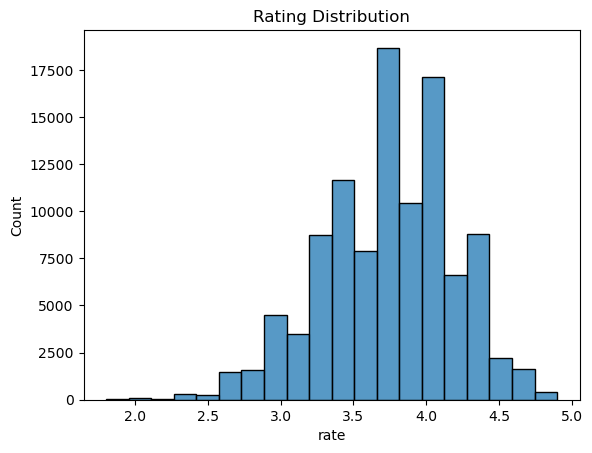

In [38]:
sns.histplot(df['rate'], bins=20)
plt.title("Rating Distribution")
plt.show()

In [39]:
cuisine_rating = df.groupby('cuisines')['rate'].mean().sort_values(ascending=False).head(10)

print(cuisine_rating)

cuisines
cantonese        4.600000
african          4.523529
singaporean      4.414894
belgian          4.366667
modern indian    4.308276
sri lankan       4.306667
malaysian        4.306422
jewish           4.300000
vegan            4.300000
german           4.285714
Name: rate, dtype: float64


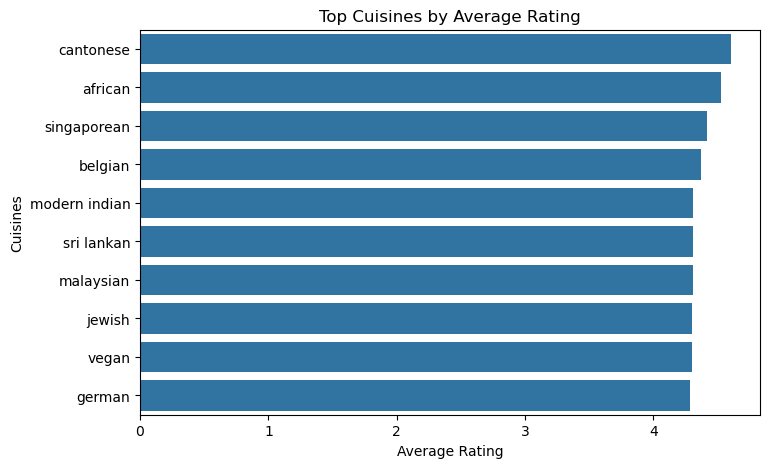

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(x=cuisine_rating.values, y=cuisine_rating.index)
plt.title("Top Cuisines by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Cuisines")
plt.show()

In [41]:
# Split cuisines
cuisines_series = df['cuisines'].dropna().str.split(', ')

# Flatten list
all_cuisines = cuisines_series.explode()

# Count
top_cuisines = all_cuisines.value_counts().head(10)

print(top_cuisines)

cuisines
north indian    17310
chinese         12930
south indian     6369
fast food        6340
continental      5202
biryani          5060
cafe             4785
desserts         4512
beverages        3839
italian          3188
Name: count, dtype: int64


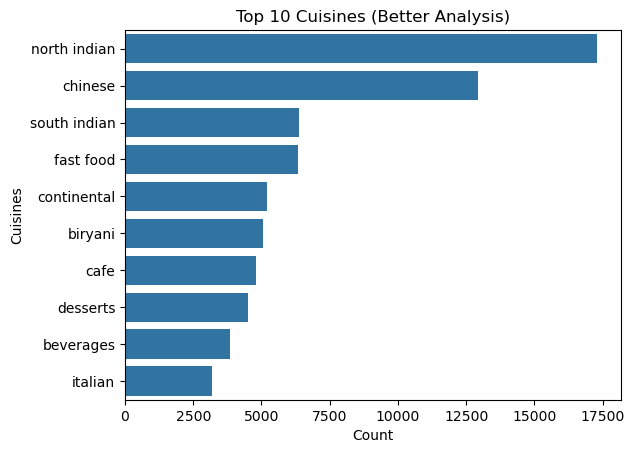

In [42]:
sns.barplot(x=top_cuisines.values, y=top_cuisines.index)
plt.title("Top 10 Cuisines (Better Analysis)")
plt.xlabel("Count")
plt.ylabel("Cuisines")
plt.show()

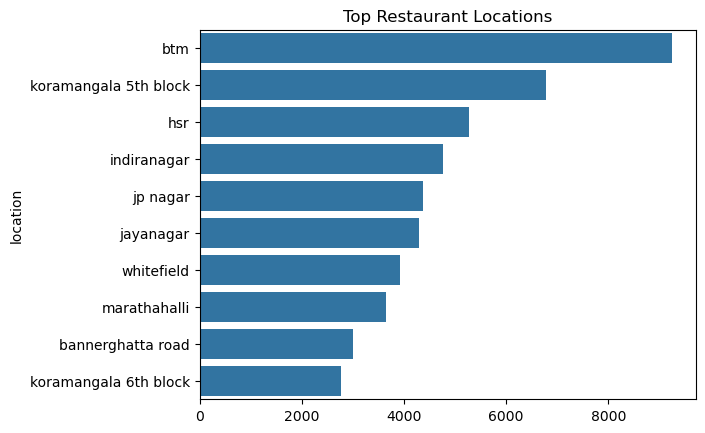

In [43]:
top_locations = df['location'].value_counts().head(10)

sns.barplot(x=top_locations.values, y=top_locations.index)
plt.title("Top Restaurant Locations")
plt.show()

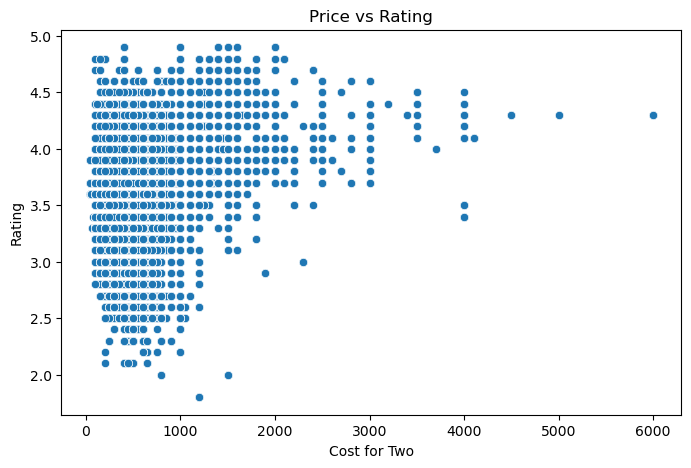

In [44]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['approx_cost(for two people)'], y=df['rate'])
plt.title("Price vs Rating")
plt.xlabel("Cost for Two")
plt.ylabel("Rating")
plt.show()

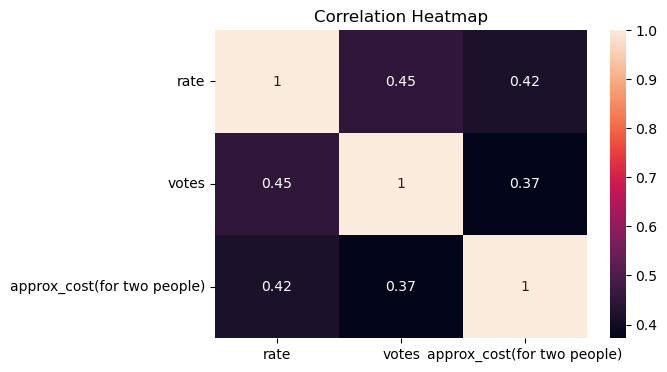

In [45]:
corr = df[['rate', 'votes', 'approx_cost(for two people)']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [18]:
import sys
!{sys.executable} -m pip install wordcloud --user

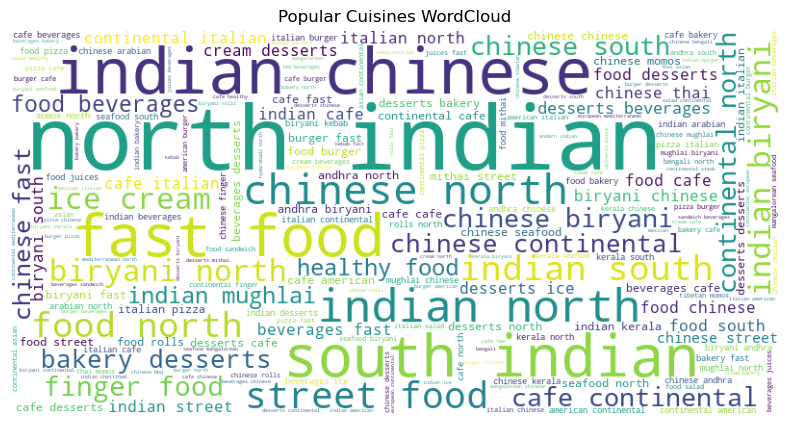

In [46]:
from wordcloud import WordCloud

text = " ".join(df['cuisines'].dropna().astype(str))

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis('off')
plt.title("Popular Cuisines WordCloud")
plt.show()

In [47]:
# Simplify cuisines (take first cuisine only)
df['cuisines'] = df['cuisines'].apply(lambda x: x.split(',')[0])

# Reduce locations (top 10 only)
top_locations = df['location'].value_counts().nlargest(10).index
df['location'] = df['location'].apply(lambda x: x if x in top_locations else 'Other')

# Reduce dataset size for speed
df = df.sample(10000, random_state=42)

In [48]:
X = df[['votes', 'approx_cost(for two people)', 'location', 'cuisines']]
y = df['rate']

# Train-Test Split

In [49]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Preprocessing - 

In [51]:
from sklearn.compose import ColumnTransformer
numeric_features = ['votes', 'approx_cost(for two people)']
categorical_features = ['location', 'cuisines']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Model (Optimized)

In [52]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=50,  
        max_depth=10,     
        random_state=42
    ))
])

# Train Model

In [53]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['votes',
                                                   'approx_cost(for two '
                                                   'people)']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['location', 'cuisines'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=10, n_estimators=50,
                                       random_state=42))])

In [54]:
# Predictions
y_pred = model.predict(X_test)

# Evaluation

In [28]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 0.30508377310002405
R2 Score: 0.5244998387485027


#  Key Insights - 

The analysis led to several important insights:
* Most restaurants have ratings between 3.5 and 4.5, indicating generally good quality
* Popular cuisines include North Indian, Chinese, and Fast Food
* Certain locations have a higher concentration of restaurants, showing business hotspots
* Cost has a weak correlation with ratings, meaning expensive restaurants are not always better
* Restaurants with more votes tend to have slightly higher ratings due to higher customer engagement



#  Recommendations for Alfido Tech Platform - 
Based on the insights, the following recommendations are proposed:
* Promote highly rated restaurants, especially in popular locations
* Use cuisine trends to provide personalized recommendations to users
* Highlight affordable restaurants with high ratings to attract budget-conscious users
* Partner with restaurants that have high customer engagement (votes and reviews) 
* Implement a review-based ranking system for better user trust and experience 